In [1]:
import requests
from bs4 import BeautifulSoup
import csv
import re

url = "https://www.turbonepal.com/new-motorcycles/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

rows_data = []

links = soup.find_all("a", href=True)

for link in links:

    text = link.get_text(" ", strip=True)

    # Only motorcycle listings
    if not text.startswith("Brand New"):
        continue

    # Get URL
    bike_url = link["href"]

    # Make complete URL
    if bike_url.startswith("/"):
        bike_url = "https://www.turbonepal.com" + bike_url

    # Extract price
    price_match = re.search(r"Rs\.\s*([\d,]+)", text)

    # Extract engine
    engine_match = re.search(r"([\d.]+)\s*cc", text)

    # Extract transmission
    transmission_match = re.search(
        r"(\d+-Speed[^•]*)", text
    )

    if price_match and engine_match and transmission_match:

        price = price_match.group(1).replace(",", "")
        engine = engine_match.group(1)
        transmission = transmission_match.group(1).strip()

        # Remove "Brand New" and price/specification part
        bike_info = text.replace("Brand New ", "", 1)

        bike_name = re.split(
            r"\s+Starting Rs\.",
            bike_info
        )[0]

        # Get brand from URL
        parts = link["href"].strip("/").split("/")

        if len(parts) >= 3:
            brand = parts[1]
        else:
            brand = "Unknown"

        rows_data.append([
            brand,
            bike_name,
            price,
            engine,
            transmission,
            bike_url
        ])

print("Total bikes scraped:", len(rows_data))

for row in rows_data[:10]:
    print(row)

Total bikes scraped: 16
['Yamaha', 'Yamaha XSR 155', '564900', '155', '6-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/XSR-155']
['Yamaha', 'Yamaha Saluto 125 Disc', '284900', '125', '4-Speed Constant-Mesh Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/Saluto-125-Disc']
['Yamaha', 'Yamaha FZ FI', '404900', '149', '5-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/FZ-FI']
['Yamaha', 'Yamaha FZ FI V2', '366900', '149', '5-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/FZ-FI-V2']
['Yamaha', 'Yamaha FZS FI V2 Rear disc brake', '384900', '149', '5-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/FZS-FI-V2']
['Yamaha', 'Yamaha FZ FI V3 BS6', '384900', '149', '5-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/FZ-FI-V3-BS6']
['Yamaha', 'Yamaha FZS FI V3 BS6 Deluxe', '430900', '149', '5-Speed Manual', 'https://www.turbonepal.com/new-motorcycles/Yamaha/FZS-FI-V3-BS6']
['Yamaha', 'Yamaha FZ S 

In [2]:
headers_list = [
    "Brand",
    "Bike Name",
    "Price",
    "Engine CC",
    "Transmission",
    "URL"
]

with open("nepal_bikes.csv", "w", newline="", encoding="utf-8") as f:

    writer = csv.writer(f)

    writer.writerow(headers_list)

    writer.writerows(rows_data)

print(f"Saved {len(rows_data)} bikes to nepal_bikes.csv")

Saved 16 bikes to nepal_bikes.csv


In [7]:
import pandas as pd

df = pd.read_csv("nepal_bikes.csv")

print(df.shape)
df.head(10)

(16, 6)


,Brand,Bike Name,Price,Engine CC,Transmission,URL
0,Yamaha,Yamaha XSR 155,564900,155.0,6-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
1,Yamaha,Yamaha Saluto 125 Disc,284900,125.0,4-Speed Constant-Mesh Manual,https://www.turbonepal.com/new-motorcycles/Yam...
2,Yamaha,Yamaha FZ FI,404900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
3,Yamaha,Yamaha FZ FI V2,366900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
4,Yamaha,Yamaha FZS FI V2 Rear disc brake,384900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
5,Yamaha,Yamaha FZ FI V3 BS6,384900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
6,Yamaha,Yamaha FZS FI V3 BS6 Deluxe,430900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
7,Yamaha,Yamaha FZ S FI New Gen,449900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
8,Yamaha,Yamaha FZ S FI Hybrid,496900,149.0,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
9,Yamaha,Yamaha MT 15 V2,581900,155.0,6-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...


In [4]:
print("Number of bikes:", len(df))
print("Columns:", df.columns.tolist())

df

Number of bikes: 16
Columns: ['Brand', 'Bike Name', 'Price', 'Engine CC', 'Transmission', 'URL']


,Brand,Bike Name,Price,Engine CC,Transmission,URL
0,Yamaha,Yamaha XSR 155,564900,155.00,6-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
1,Yamaha,Yamaha Saluto 125 Disc,284900,125.00,4-Speed Constant-Mesh Manual,https://www.turbonepal.com/new-motorcycles/Yam...
2,Yamaha,Yamaha FZ FI,404900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
3,Yamaha,Yamaha FZ FI V2,366900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
4,Yamaha,Yamaha FZS FI V2 Rear disc brake,384900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
5,Yamaha,Yamaha FZ FI V3 BS6,384900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
6,Yamaha,Yamaha FZS FI V3 BS6 Deluxe,430900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
7,Yamaha,Yamaha FZ S FI New Gen,449900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
8,Yamaha,Yamaha FZ S FI Hybrid,496900,149.00,5-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...
9,Yamaha,Yamaha MT 15 V2,581900,155.00,6-Speed Manual,https://www.turbonepal.com/new-motorcycles/Yam...


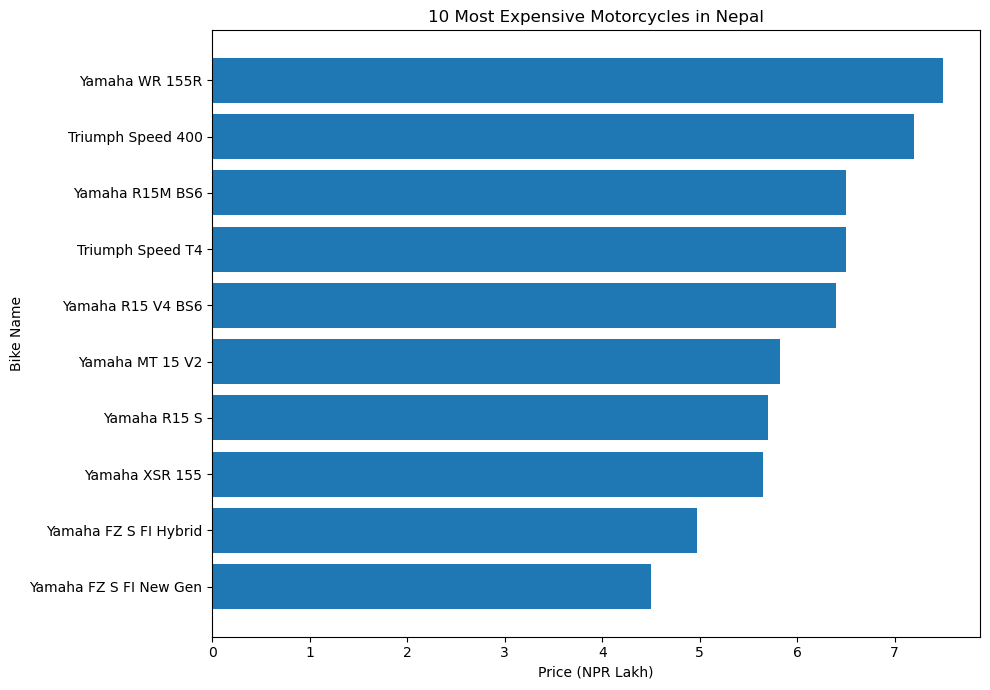

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("nepal_bikes.csv")

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

top_bikes = df.sort_values("Price", ascending=False).head(10)

# Convert NPR to lakh
top_bikes["Price_Lakh"] = top_bikes["Price"] / 100000

plt.figure(figsize=(10, 7))

plt.barh(
    top_bikes["Bike Name"],
    top_bikes["Price_Lakh"]
)

plt.title("10 Most Expensive Motorcycles in Nepal")
plt.xlabel("Price (NPR Lakh)")
plt.ylabel("Bike Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()